# 3 · Rezultati i robustnost

Metrike: **AbsRel** (nizi bolji), **RMSE** (m, nizi bolji), **delta1** (visi bolji).
Svi modeli evaluirani na cistom test skupu i na 9 degradiranih (3 tipa x 3 jacine),
**bez ponovnog treniranja**.

In [1]:
import os, sys
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')            # run from the repo root so paths resolve
sys.path.insert(0, 'src')
sys.path.insert(0, 'scripts')

import json
import numpy as np
import matplotlib.pyplot as plt

data = json.loads(Path('outputs/robustness.json').read_text())
da = json.loads(Path('outputs/robustness_da.json').read_text())
data['05_depth_anything_nyu'] = da['05_depth_anything_nyu']   # median-poravnata verzija
order = ['01_resnet50_nyu', '02_sd_unet_nyu', '03_ijepa_nyu', '04_fusion_nyu', '05_depth_anything_nyu']
labels = dict([('01_resnet50_nyu', 'ResNet-50'), ('02_sd_unet_nyu', 'SD-UNet'), ('03_ijepa_nyu', 'I-JEPA'), ('04_fusion_nyu', 'Fusion'), ('05_depth_anything_nyu', 'DepthAnything')])

## Cist test skup

model              AbsRel    RMSE   delta1
ResNet-50          0.1376   0.495   0.8224
SD-UNet            0.0802   0.311   0.9467
I-JEPA             0.1314   0.488   0.8329
Fusion             0.0827   0.322   0.9410
DepthAnything      0.0688   0.324   0.9497


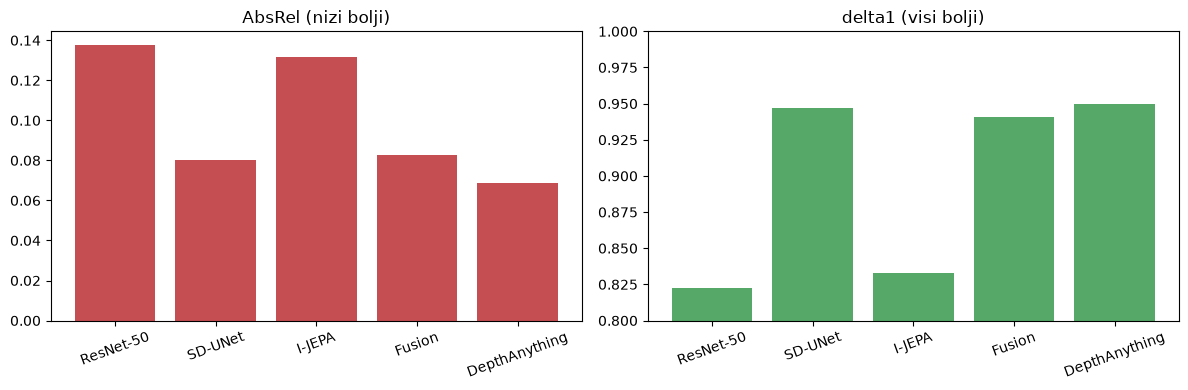

In [2]:
print(f"{'model':16s}{'AbsRel':>9s}{'RMSE':>8s}{'delta1':>9s}")
for k in order:
    c = data[k]['clean']
    print(f"{labels[k]:16s}{c['abs_rel']:9.4f}{c['rmse']:8.3f}{c['delta1']:9.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
names = [labels[k] for k in order]
ax[0].bar(names, [data[k]['clean']['abs_rel'] for k in order], color='#c44e52')
ax[0].set_title('AbsRel (nizi bolji)')
ax[1].bar(names, [data[k]['clean']['delta1'] for k in order], color='#55a868')
ax[1].set_title('delta1 (visi bolji)'); ax[1].set_ylim(0.8, 1.0)
for a in ax:
    a.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

**Zamrznute SD osobine skoro dostizu SOTA.** SD-UNet (0.080) je na korak od DepthAnything
(0.069), koji uz to dobija GT-median skalu. Fuzija ne pobedjuje sam SD - SD osobine vec nose
geometriju. Svi frozen pristupi biju nadgledani ResNet-50 baseline.

## Robustnost: delta1 po jacini degradacije

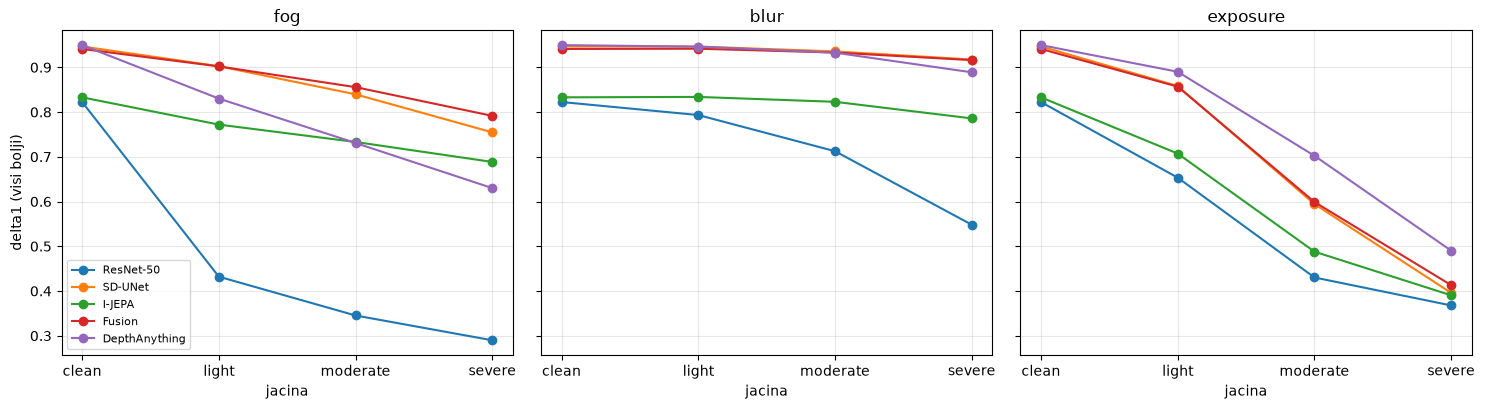

In [3]:
degs = ['fog', 'blur', 'exposure']
xs = ['clean', 'light', 'moderate', 'severe']
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, deg in zip(axes, degs):
    for k in order:
        ys = [data[k]['clean']['delta1']] + [data[k][f'{deg}/{s}']['delta1'] for s in xs[1:]]
        ax.plot(xs, ys, marker='o', label=labels[k])
    ax.set_title(deg); ax.set_xlabel('jacina'); ax.grid(alpha=0.3)
axes[0].set_ylabel('delta1 (visi bolji)')
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Nalazi robustnosti.**

- **Zamucenje je skoro bezopasno** za frozen enkodere (SD, Fuzija, DepthAnything jedva padaju) -
  semanticke osobine ne zavise od visokih frekvencija. Baseline je izuzetak i naglo pada.
- **Ekspozicija je univerzalni otkaz** - svi modeli se urusavaju pri jakom zatamnjenju
  (delta1 ~0.4). To je bezbednosno kriticni scenario nocne voznje.
- **Trenirani SD je robusniji na maglu od zero-shot DepthAnything** (0.148 vs 0.251 AbsRel, severe).
- **Nadgledani baseline je najmanje robustan** u svim uslovima - robustnost dolazi od
  predtreniranih osobina, ne od broja treniranih parametara.